Projeler: Senin listenden 7 tane:

Yapay Sinir Ağları ile Görüntü Sınıflandırma (MLP) -yapmıştım tekrar yapmicam

CNN ile Rakam Görüntüsü Sınıflandırma (MNIST) -yapmıştım tekrar yapmicam

LSTM ile Film Yorumları Duygu Analizi

GAN ile Görüntü Oluşturma

Transformers ile Duygu Analizi (Text)

Autoencoder ile Moda Görüntüleri (Fashion-MNIST)

Transfer Learning ile İlaç Görüntüleri Sınıflandırma

PROJE — MLP (Multi-Layer Perceptron)**kalın metin**

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


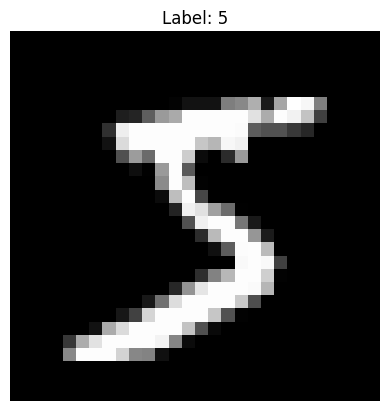

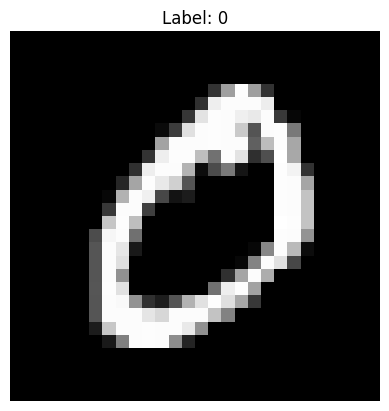

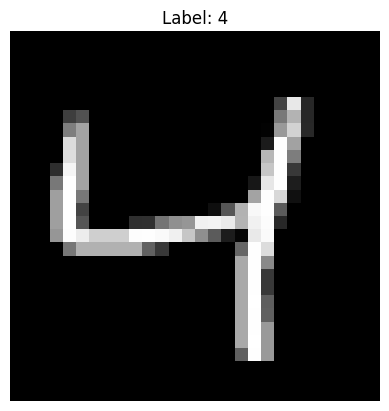

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9199 - loss: 0.2725 - val_accuracy: 0.9575 - val_loss: 0.1409
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9659 - loss: 0.1131 - val_accuracy: 0.9600 - val_loss: 0.1259
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0782 - val_accuracy: 0.9676 - val_loss: 0.1083
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9815 - loss: 0.0593 - val_accuracy: 0.9718 - val_loss: 0.0910
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0424 - val_accuracy: 0.9722 - val_loss: 0.1048
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9734 - loss: 0.0962
MLP Accuracy: 0.9733999967575073
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


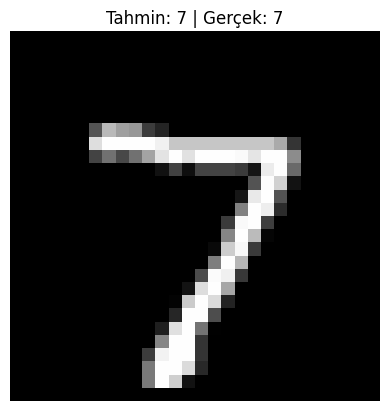

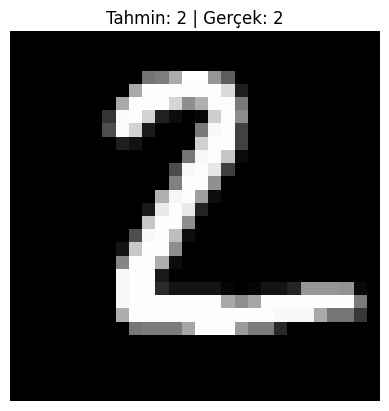

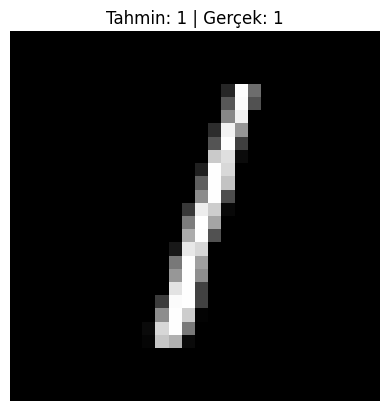

In [5]:
# =========================
# 📌 KÜTÜPHANELER
# =========================

import tensorflow as tf  # Derin öğrenme framework'ü
from tensorflow import keras  # Keras API
from tensorflow.keras import layers  # Katmanlar
import matplotlib.pyplot as plt  # Görselleştirme

# =========================
# 📌 VERİ SETİ
# =========================

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()  # MNIST veri seti

print("Train shape:", X_train.shape)  # Eğitim veri boyutu
print("Test shape:", X_test.shape)  # Test veri boyutu

# =========================
# 📌 VERİYİ GÖR
# =========================

for i in range(3):  # İlk 3 görüntüyü göster
    plt.imshow(X_train[i], cmap='gray')  # Görüntü çiz
    plt.title(f"Label: {y_train[i]}")  # Etiket yaz
    plt.axis('off')  # Ekseni kaldır
    plt.show()  # Göster

# =========================
# 📌 VERİ HAZIRLAMA
# =========================

X_train = X_train / 255.0  # Normalize (0-255 → 0-1)
X_test = X_test / 255.0  # Normalize

X_train = X_train.reshape(-1, 784)  # Flatten (28x28 → 784)
X_test = X_test.reshape(-1, 784)  # Flatten

# =========================
# 📌 MODEL OLUŞTUR
# =========================

model = keras.Sequential([  # Model başlat
    layers.Dense(128, activation='relu', input_shape=(784,)),  # 1. katman
    layers.Dense(64, activation='relu'),  # 2. katman
    layers.Dense(10, activation='softmax')  # Çıkış katmanı
])

# =========================
# 📌 MODEL DERLE
# =========================

model.compile(
    optimizer='adam',  # Öğrenme algoritması
    loss='sparse_categorical_crossentropy',  # Hata fonksiyonu
    metrics=['accuracy']  # Başarı metriği
)

model.summary()  # Model yapısı

# =========================
# 📌 MODEL EĞİT
# =========================

model.fit(
    X_train, y_train,  # Eğitim verisi
    epochs=5,  # Epoch sayısı
    batch_size=32,  # Batch size
    validation_split=0.2  # Validation
)

# =========================
# 📌 TEST
# =========================

loss, acc = model.evaluate(X_test, y_test)  # Test et
print("MLP Accuracy:", acc)  # Accuracy yazdır

# =========================
# 📌 TAHMİN
# =========================

predictions = model.predict(X_test)  # Tahmin yap

for i in range(3):  # İlk 3 sonucu göster
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')  # Görüntü
    plt.title(f"Tahmin: {predictions[i].argmax()} | Gerçek: {y_test[i]}")  # Tahmin vs gerçek
    plt.axis('off')  # Ekseni kaldır
    plt.show()  # Göster

PROJE — CNN (Convolutional Neural Network)**kalın metin**

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.8742 - loss: 0.3962 - val_accuracy: 0.9857 - val_loss: 0.0453
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9520 - loss: 0.1603 - val_accuracy: 0.9880 - val_loss: 0.0325
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9637 - loss: 0.1200 - val_accuracy: 0.9908 - val_loss: 0.0278
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9703 - loss: 0.1000 - val_accuracy: 0.9912 - val_loss: 0.0273
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9739 - loss: 0.0877 - val_accuracy: 0.9929 - val_loss: 0.0214
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9929 - loss: 0.0214
CNN Accuracy: 0.992900013923645
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


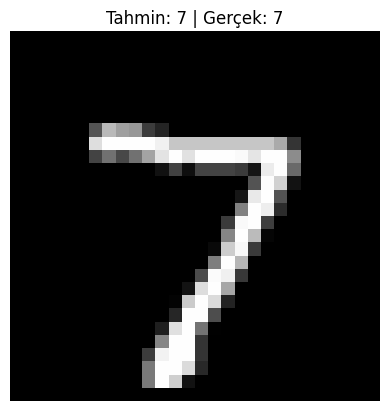

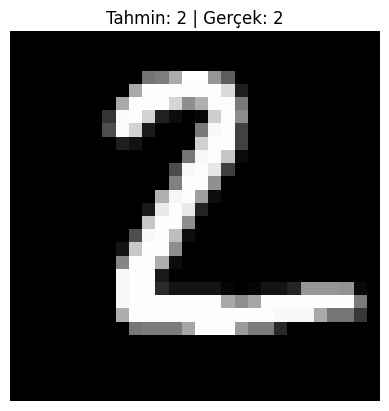

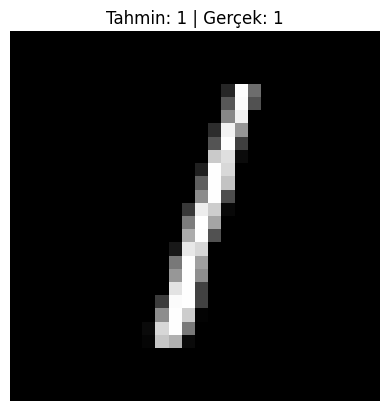

In [6]:
# =========================
# 📌 KÜTÜPHANELER
# =========================

import tensorflow as tf  # Derin öğrenme framework'ü
from tensorflow import keras  # Keras API
from tensorflow.keras import layers  # Katmanlar
import matplotlib.pyplot as plt  # Görselleştirme

# =========================
# 📌 VERİ SETİ
# =========================

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()  # MNIST veri seti

print("Train shape:", X_train.shape)  # Eğitim veri boyutu
print("Test shape:", X_test.shape)  # Test veri boyutu

# =========================
# 📌 VERİ HAZIRLAMA
# =========================

X_train = X_train / 255.0  # Normalize
X_test = X_test / 255.0  # Normalize

X_train = X_train.reshape(-1, 28, 28, 1)  # CNN için reshape
X_test = X_test.reshape(-1, 28, 28, 1)  # Test reshape

# =========================
# 📌 DATA AUGMENTATION
# =========================

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Veri artırma

datagen = ImageDataGenerator(
    rotation_range=10,  # Döndürme
    zoom_range=0.1,  # Zoom
    width_shift_range=0.1,  # Yatay kaydırma
    height_shift_range=0.1  # Dikey kaydırma
)

datagen.fit(X_train)  # Eğitim verisine uygula

# =========================
# 📌 MODEL OLUŞTUR
# =========================

model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # Conv katmanı
    layers.MaxPooling2D(2,2),  # Pooling

    layers.Conv2D(64, (3,3), activation='relu'),  # Conv katmanı
    layers.MaxPooling2D(2,2),  # Pooling

    layers.Flatten(),  # Düzleştir

    layers.Dense(128, activation='relu'),  # Dense
    layers.Dropout(0.5),  # Overfitting önleme

    layers.Dense(10, activation='softmax')  # Output
])

# =========================
# 📌 MODEL DERLE
# =========================

model.compile(
    optimizer='adam',  # Öğrenme algoritması
    loss='sparse_categorical_crossentropy',  # Loss
    metrics=['accuracy']  # Accuracy
)

model.summary()  # Model yapısı

# =========================
# 📌 MODEL EĞİT
# =========================

model.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # Augmented veri
    epochs=5,  # Epoch
    validation_data=(X_test, y_test)  # Validation
)

# =========================
# 📌 TEST
# =========================

loss, acc = model.evaluate(X_test, y_test)  # Test et
print("CNN Accuracy:", acc)  # Accuracy yazdır

# =========================
# 📌 TAHMİN
# =========================

predictions = model.predict(X_test)  # Tahmin

for i in range(3):  # İlk 3 sonuç
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')  # Görüntü
    plt.title(f"Tahmin: {predictions[i].argmax()} | Gerçek: {y_test[i]}")  # Tahmin vs gerçek
    plt.axis('off')  # Ekseni kaldır
    plt.show()  # Göster